# 📊 Exploratory Data Analysis (EDA)
## Employee Attrition Prediction

**Objective**: Understand the IBM HR dataset, discover patterns, and identify key factors driving employee attrition.

**Analysis Breakdown**:
1. Dataset Overview & Quality Check
2. Univariate Analysis — Distribution of key features
3. Bivariate Analysis — Attrition vs key drivers
4. Correlation Heatmap — Feature relationships
5. Key Insights & Takeaways

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('Libraries loaded successfully! ✅')

Libraries loaded successfully! ✅


## 1. Dataset Overview & Quality Check

In [2]:
# Load the dataset
df = pd.read_csv('../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(f'Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

Dataset Shape: 1470 rows × 35 columns


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
# Data types and missing values
print('='*60)
print('DATA TYPES & NULL CHECK')
print('='*60)
print(f'\nMissing values: {df.isnull().sum().sum()}')
print(f'Duplicate rows: {df.duplicated().sum()}')
print(f'\nColumn types:')
print(df.dtypes.value_counts())
df.info()

DATA TYPES & NULL CHECK

Missing values: 0
Duplicate rows: 0

Column types:
int64     26
object     9
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  Hour

In [4]:
# Statistical summary
df.describe().round(2)

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.00,1470.00,1470.00,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,...,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,802.49,9.19,2.91,1.0,1024.87,2.72,65.89,2.73,2.06,...,2.71,80.0,0.79,11.28,2.80,2.76,7.01,4.23,2.19,4.12
std,9.14,403.51,8.11,1.02,0.0,602.02,1.09,20.33,0.71,1.11,...,1.08,0.0,0.85,7.78,1.29,0.71,6.13,3.62,3.22,3.57
min,18.00,102.00,1.00,1.00,1.0,1.00,1.00,30.00,1.00,1.00,...,1.00,80.0,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,30.00,465.00,2.00,2.00,1.0,491.25,2.00,48.00,2.00,1.00,...,2.00,80.0,0.00,6.00,2.00,2.00,3.00,2.00,0.00,2.00
50%,36.00,802.00,7.00,3.00,1.0,1020.50,3.00,66.00,3.00,2.00,...,3.00,80.0,1.00,10.00,3.00,3.00,5.00,3.00,1.00,3.00
75%,43.00,1157.00,14.00,4.00,1.0,1555.75,4.00,83.75,3.00,3.00,...,4.00,80.0,1.00,15.00,3.00,3.00,9.00,7.00,3.00,7.00
max,60.00,1499.00,29.00,5.00,1.0,2068.00,4.00,100.00,4.00,5.00,...,4.00,80.0,3.00,40.00,6.00,4.00,40.00,18.00,15.00,17.00


In [5]:
# Check columns with single unique value (no predictive power)
print('Columns with single unique value (constant):')
for col in df.columns:
    if df[col].nunique() == 1:
        print(f'  → {col}: {df[col].unique()[0]}')

Columns with single unique value (constant):
  → EmployeeCount: 1
  → Over18: Y
  → StandardHours: 80


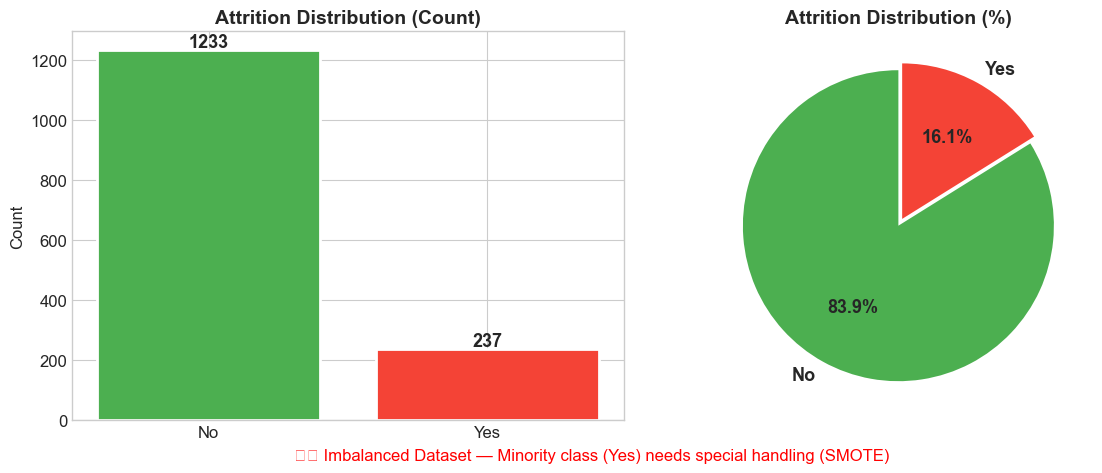

In [6]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
attrition_counts = df['Attrition'].value_counts()
colors = ['#4CAF50', '#F44336']
axes[0].bar(attrition_counts.index, attrition_counts.values, color=colors, edgecolor='white', linewidth=2)
axes[0].set_title('Attrition Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(attrition_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold', fontsize=13)

# Pie chart
axes[1].pie(attrition_counts.values, labels=attrition_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0, 0.05),
            textprops={'fontsize': 13, 'fontweight': 'bold'})
axes[1].set_title('Attrition Distribution (%)', fontsize=14, fontweight='bold')

plt.suptitle('⚠️ Imbalanced Dataset — Minority class (Yes) needs special handling (SMOTE)', 
             fontsize=12, y=0.02, color='red')
plt.tight_layout()
plt.savefig('../outputs/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Univariate Analysis
Examine the distribution of key numerical and categorical features.

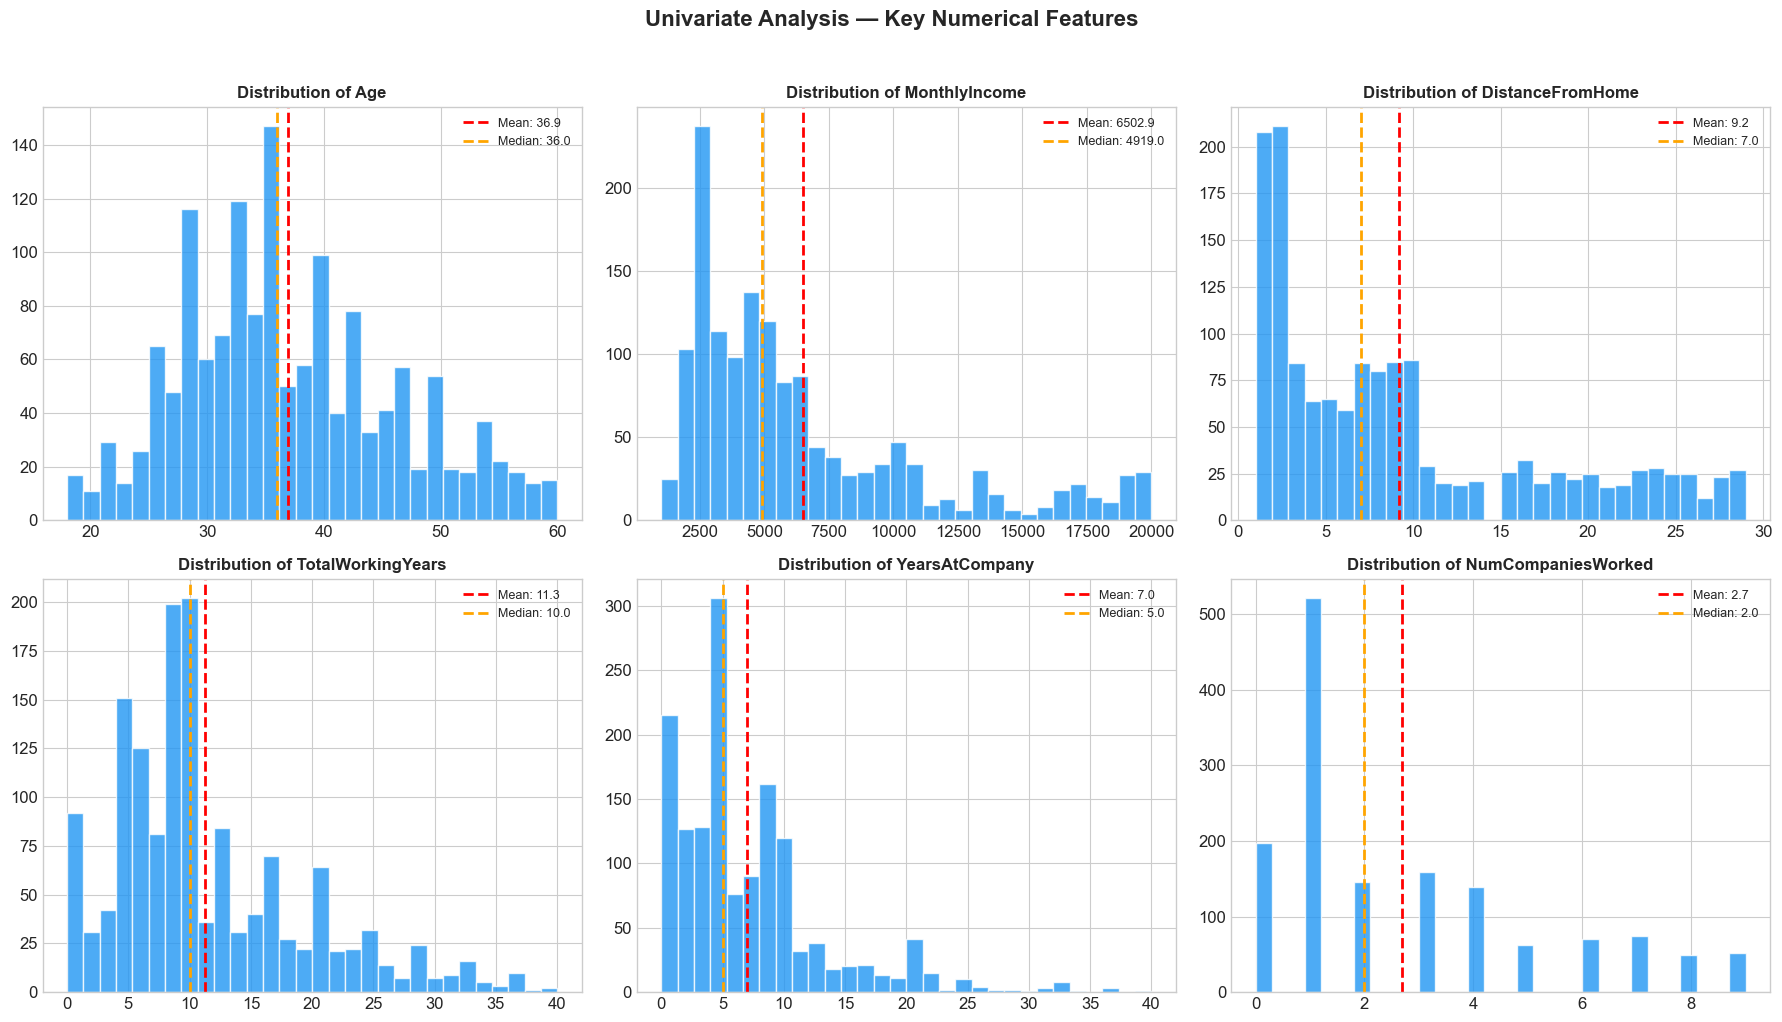

In [7]:
# Distribution of key numerical features
num_features = ['Age', 'MonthlyIncome', 'DistanceFromHome', 'TotalWorkingYears', 
                'YearsAtCompany', 'NumCompaniesWorked']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].hist(df[col], bins=30, color='#2196F3', edgecolor='white', alpha=0.8)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {df[col].median():.1f}')
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].legend(fontsize=9)

plt.suptitle('Univariate Analysis — Key Numerical Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/univariate_numerical.png', dpi=150, bbox_inches='tight')
plt.show()

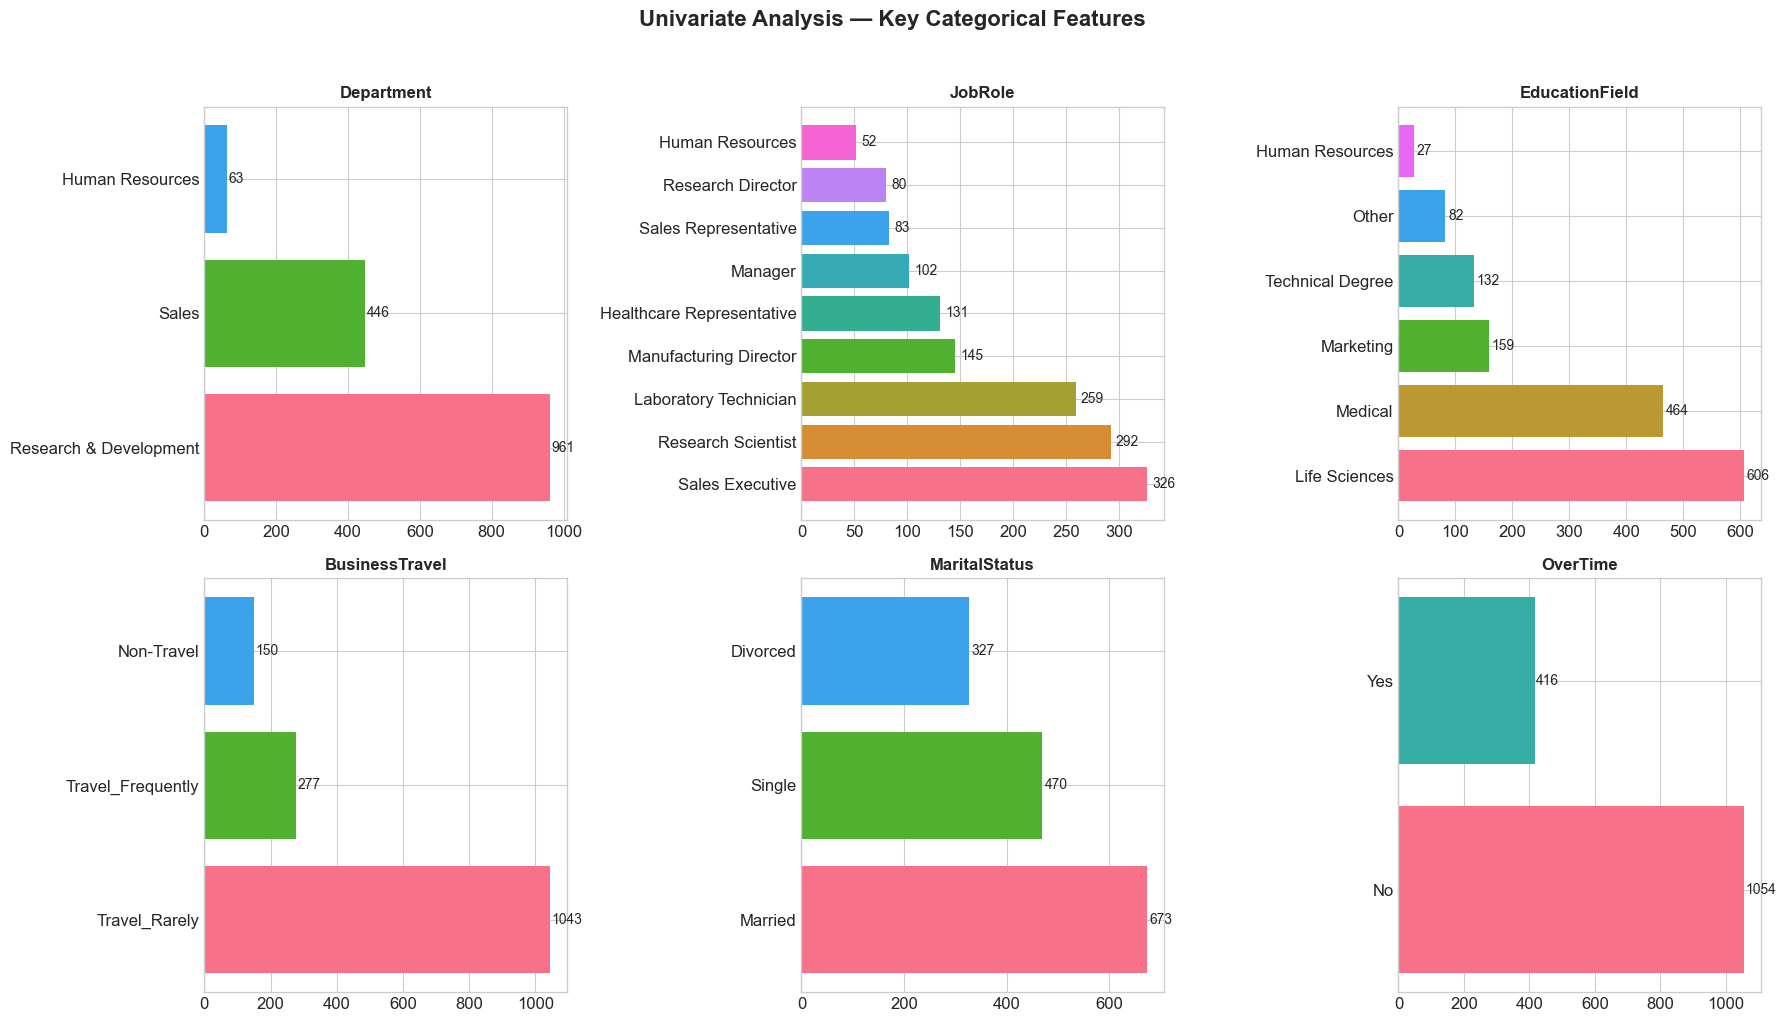

In [8]:
# Distribution of key categorical features
cat_features = ['Department', 'JobRole', 'EducationField', 'BusinessTravel', 
                'MaritalStatus', 'OverTime']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    counts = df[col].value_counts()
    axes[i].barh(counts.index, counts.values, color=sns.color_palette('husl', len(counts)))
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    for j, v in enumerate(counts.values):
        axes[i].text(v + 5, j, str(v), va='center', fontsize=10)

plt.suptitle('Univariate Analysis — Key Categorical Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/univariate_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Bivariate Analysis
How do key features relate to Attrition?

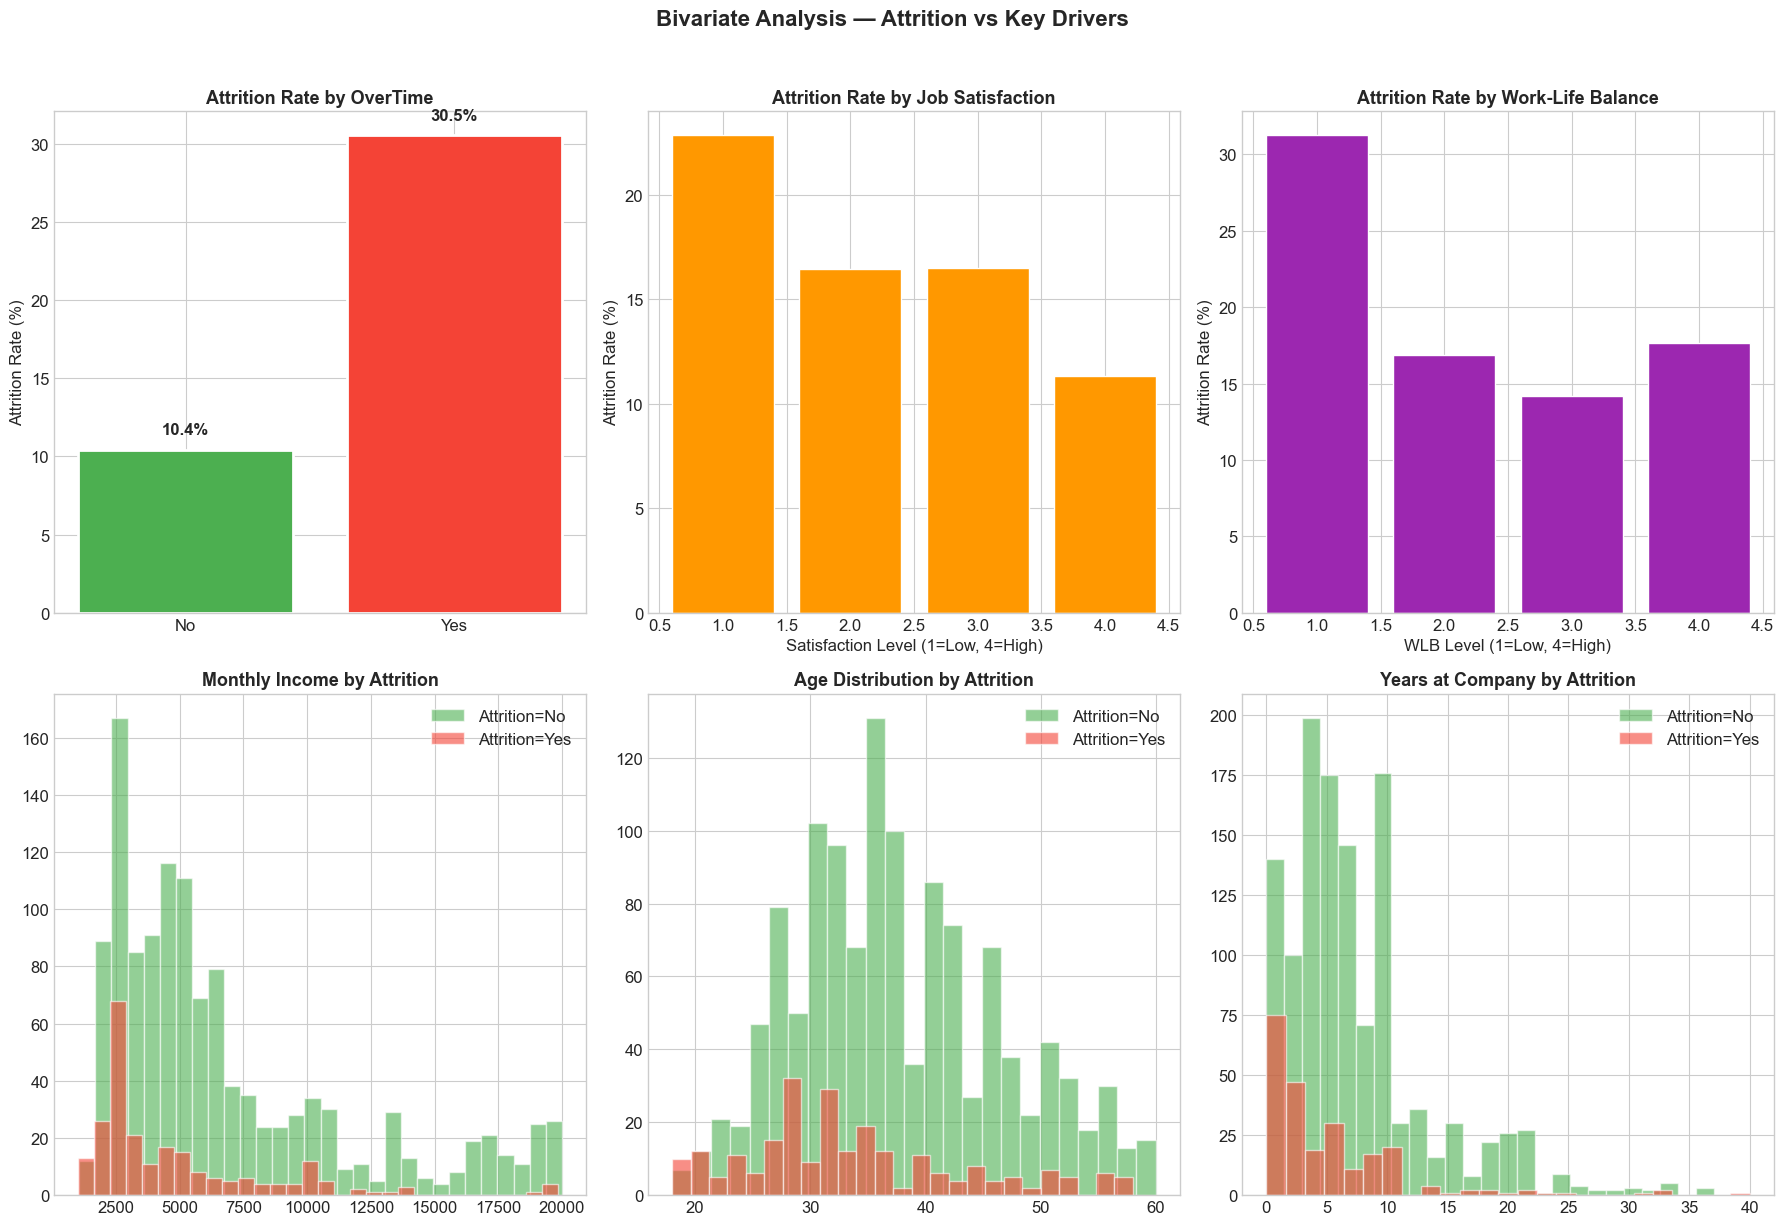

In [9]:
# Attrition rate by OverTime
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. OverTime vs Attrition
overtime_attrition = df.groupby('OverTime')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100)
axes[0, 0].bar(overtime_attrition.index, overtime_attrition.values, 
               color=['#4CAF50', '#F44336'], edgecolor='white', linewidth=2)
axes[0, 0].set_title('Attrition Rate by OverTime', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Attrition Rate (%)')
for i, v in enumerate(overtime_attrition.values):
    axes[0, 0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)

# 2. JobSatisfaction vs Attrition
sat_attrition = df.groupby('JobSatisfaction')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100)
axes[0, 1].bar(sat_attrition.index, sat_attrition.values, color='#FF9800', edgecolor='white')
axes[0, 1].set_title('Attrition Rate by Job Satisfaction', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Satisfaction Level (1=Low, 4=High)')
axes[0, 1].set_ylabel('Attrition Rate (%)')

# 3. WorkLifeBalance vs Attrition
wlb_attrition = df.groupby('WorkLifeBalance')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100)
axes[0, 2].bar(wlb_attrition.index, wlb_attrition.values, color='#9C27B0', edgecolor='white')
axes[0, 2].set_title('Attrition Rate by Work-Life Balance', fontsize=13, fontweight='bold')
axes[0, 2].set_xlabel('WLB Level (1=Low, 4=High)')
axes[0, 2].set_ylabel('Attrition Rate (%)')

# 4. MonthlyIncome distribution by Attrition
for label, color in [('No', '#4CAF50'), ('Yes', '#F44336')]:
    subset = df[df['Attrition'] == label]['MonthlyIncome']
    axes[1, 0].hist(subset, bins=30, alpha=0.6, color=color, label=f'Attrition={label}', edgecolor='white')
axes[1, 0].set_title('Monthly Income by Attrition', fontsize=13, fontweight='bold')
axes[1, 0].legend()

# 5. Age distribution by Attrition
for label, color in [('No', '#4CAF50'), ('Yes', '#F44336')]:
    subset = df[df['Attrition'] == label]['Age']
    axes[1, 1].hist(subset, bins=25, alpha=0.6, color=color, label=f'Attrition={label}', edgecolor='white')
axes[1, 1].set_title('Age Distribution by Attrition', fontsize=13, fontweight='bold')
axes[1, 1].legend()

# 6. YearsAtCompany distribution by Attrition
for label, color in [('No', '#4CAF50'), ('Yes', '#F44336')]:
    subset = df[df['Attrition'] == label]['YearsAtCompany']
    axes[1, 2].hist(subset, bins=25, alpha=0.6, color=color, label=f'Attrition={label}', edgecolor='white')
axes[1, 2].set_title('Years at Company by Attrition', fontsize=13, fontweight='bold')
axes[1, 2].legend()

plt.suptitle('Bivariate Analysis — Attrition vs Key Drivers', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/bivariate_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

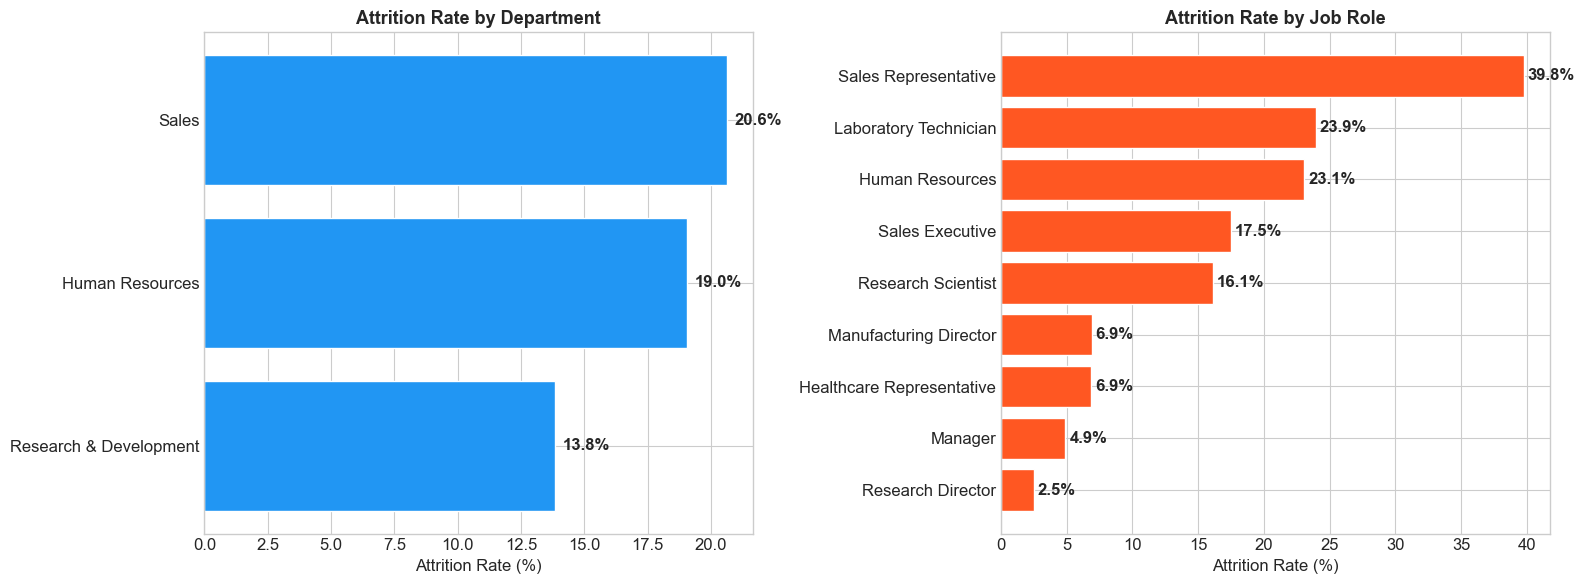

In [10]:
# Attrition rate by Department and JobRole
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Department
dept_attrition = df.groupby('Department')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=True)
axes[0].barh(dept_attrition.index, dept_attrition.values, color='#2196F3', edgecolor='white')
axes[0].set_title('Attrition Rate by Department', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Attrition Rate (%)')
for i, v in enumerate(dept_attrition.values):
    axes[0].text(v + 0.3, i, f'{v:.1f}%', va='center', fontweight='bold')

# JobRole
role_attrition = df.groupby('JobRole')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=True)
axes[1].barh(role_attrition.index, role_attrition.values, color='#FF5722', edgecolor='white')
axes[1].set_title('Attrition Rate by Job Role', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Attrition Rate (%)')
for i, v in enumerate(role_attrition.values):
    axes[1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/attrition_by_role_dept.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Correlation Heatmap

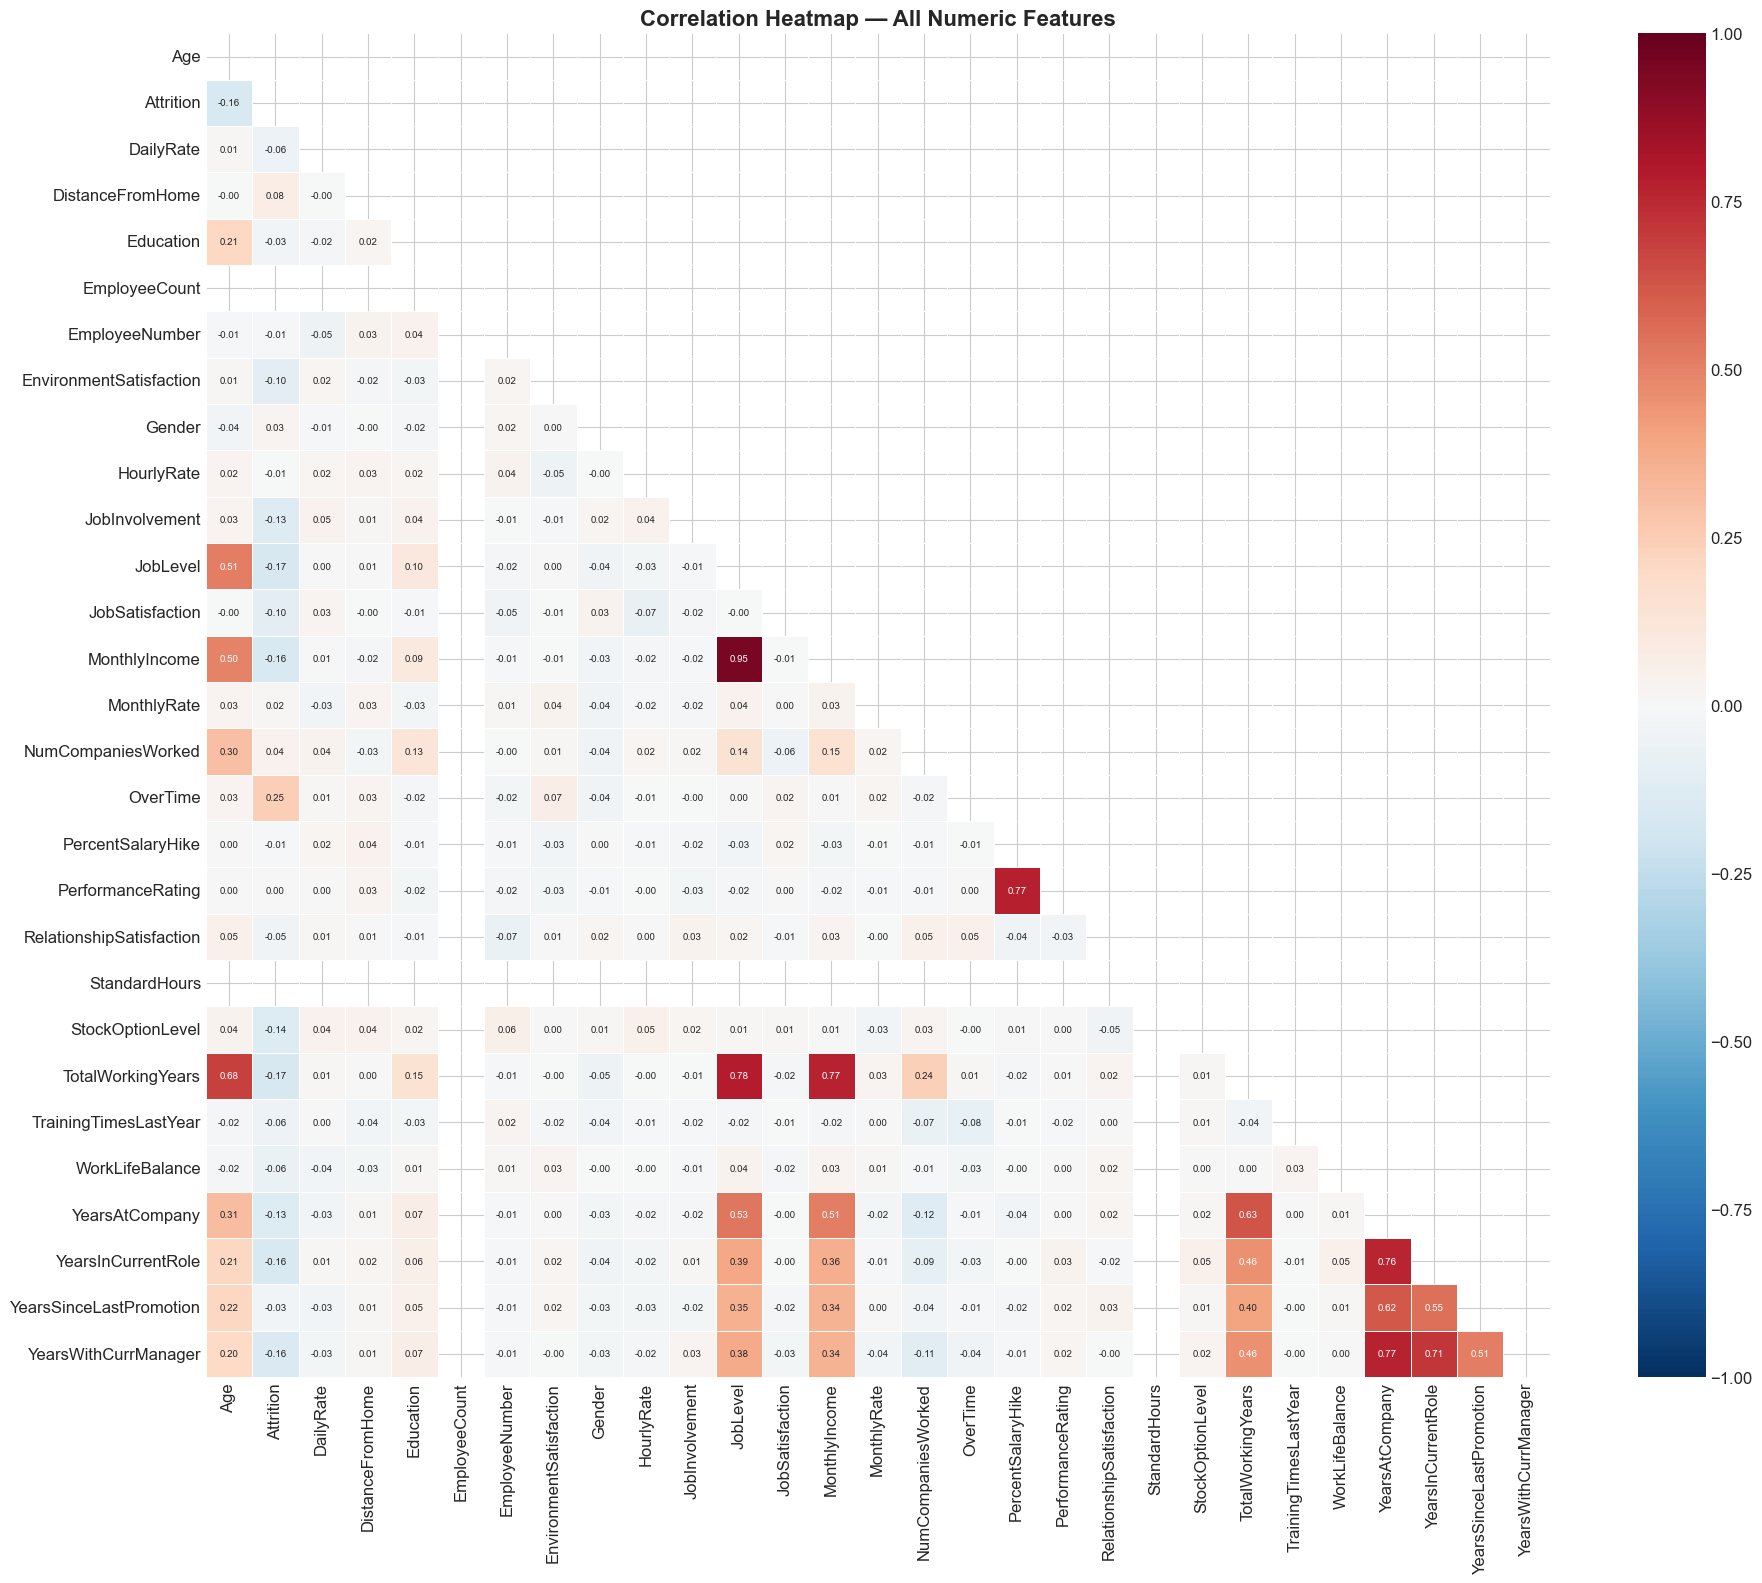

In [11]:
# Encode Attrition for correlation
df_corr = df.copy()
df_corr['Attrition'] = df_corr['Attrition'].map({'Yes': 1, 'No': 0})
df_corr['OverTime'] = df_corr['OverTime'].map({'Yes': 1, 'No': 0})
df_corr['Gender'] = df_corr['Gender'].map({'Male': 1, 'Female': 0})

# Select numeric columns
numeric_cols = df_corr.select_dtypes(include=[np.number]).columns
corr_matrix = df_corr[numeric_cols].corr()

# Full heatmap
fig, ax = plt.subplots(figsize=(20, 16))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            annot_kws={'size': 7}, ax=ax)
ax.set_title('Correlation Heatmap — All Numeric Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

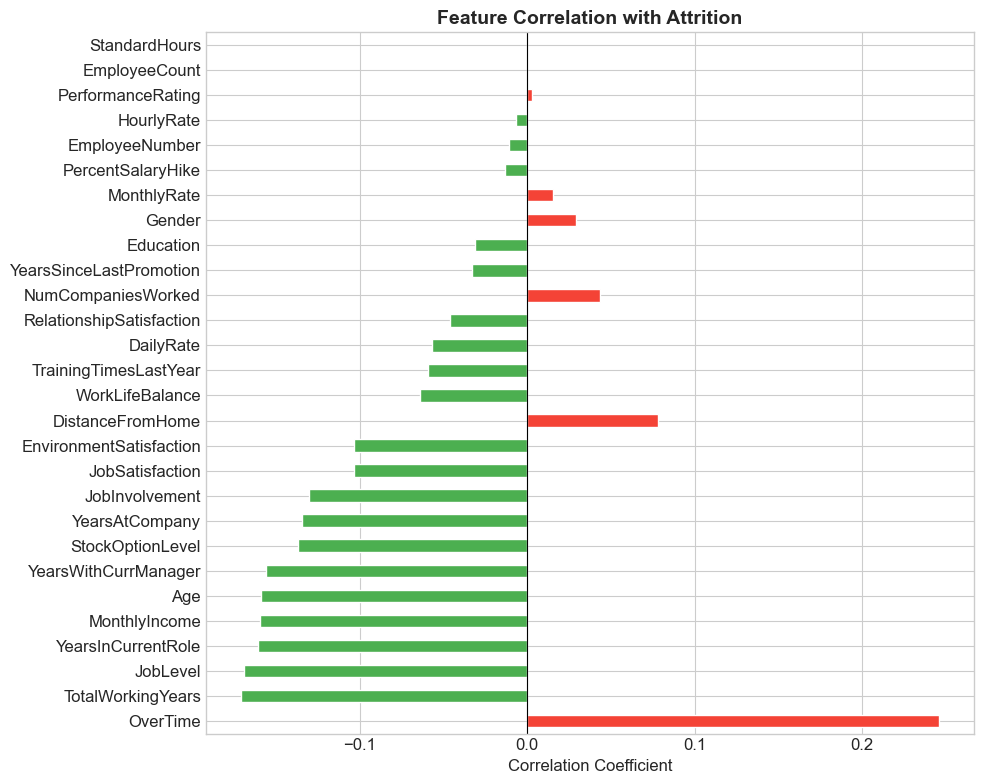


Top 10 features most correlated with Attrition:
OverTime                0.2461
TotalWorkingYears      -0.1711
JobLevel               -0.1691
YearsInCurrentRole     -0.1605
MonthlyIncome          -0.1598
Age                    -0.1592
YearsWithCurrManager   -0.1562
StockOptionLevel       -0.1371
YearsAtCompany         -0.1344
JobInvolvement         -0.1300


In [12]:
# Top features correlated with Attrition
attrition_corr = corr_matrix['Attrition'].drop('Attrition').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#F44336' if x > 0 else '#4CAF50' for x in attrition_corr.values]
attrition_corr.plot(kind='barh', color=colors, edgecolor='white', ax=ax)
ax.set_title('Feature Correlation with Attrition', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../outputs/attrition_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 features most correlated with Attrition:')
print(attrition_corr.head(10).round(4).to_string())

## 5. Key Insights & Takeaways

### 🔍 Key Findings:

1. **Imbalanced Dataset**: Only **16.1%** of employees left (237 Yes vs 1,233 No). We'll need **SMOTE** to handle this class imbalance during modeling.

2. **OverTime is the #1 Correlated Feature** (r = 0.246): Employees who work overtime have an attrition rate of **30.5%** compared to **10.4%** for those who don't — nearly **3x higher**.

3. **Income Gap**: Employees who leave earn significantly less (mean **$4,787** vs **$6,833** for those who stay). Median shows an even starker gap ($3,202 vs $5,204). Compensation fairness is a key retention factor.

4. **Job Satisfaction**: Satisfaction Level 1 has the highest attrition (**22.8%**), while Level 4 has the lowest (**11.3%**). However, Level 2 (16.4%) and Level 3 (16.5%) are nearly identical — the relationship is **not perfectly linear**.

5. **Early Tenure is the Danger Zone**: Employees who leave have a median tenure of **3 years** vs **6 years** for those who stay. The first 2–3 years are the critical retention window.

6. **Age Factor**: The **18–25 age group** has the highest attrition rate at **35.8%**, followed by 26–35 at 19.1%. Interestingly, 56–65 also shows elevated attrition (17.0%), likely due to retirement. The most stable group is **36–45** (9.2%).

7. **Top Correlations with Attrition**: OverTime (+0.246), TotalWorkingYears (−0.171), JobLevel (−0.169), YearsInCurrentRole (−0.161), MonthlyIncome (−0.160). Negative correlations mean more experience/income → less likely to leave.

### 📌 Next Steps:
- Proceed to **Notebook 02** for Data Preprocessing & Feature Engineering
- Create composite features like `Income_per_Age` and `Satisfaction_Score`
- Apply SMOTE on training data to handle imbalance